# adap-eps-greedy z profiles

This notebook loads z-profile `.txt` files from `../data/adap_eps_greedy/profiles/`.

It includes:
- individual profile plots
- grouped mean curves
- **±1 SE shading** when there are multiple profiles in the same `(model, reward, n_steps)` group

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 12,
})

In [2]:
BASE_DIR = Path('../data/adap_eps_greedy/profiles')
PROFILE_FILES = sorted(BASE_DIR.rglob('*.txt'))

rows = []
for fp in PROFILE_FILES:
    parts = fp.parts
    # expected layout: .../profiles/<MODEL>/<REWARD>/<file>.txt
    model = parts[-3] if len(parts) >= 3 else 'UNKNOWN'
    reward = parts[-2] if len(parts) >= 2 else 'UNKNOWN'

    z = np.atleast_1d(np.loadtxt(fp, dtype=float)).astype(float)
    rows.append({
        'path': str(fp),
        'profile_id': fp.stem,
        'model': model,
        'reward': reward,
        'n_steps': int(z.shape[0]),
        'z_mean': float(np.nanmean(z)),
        'z_min': float(np.nanmin(z)),
        'z_max': float(np.nanmax(z)),
        'z_values': z,
    })

profiles_df = pd.DataFrame(rows)
if profiles_df.empty:
    raise RuntimeError(f'No .txt profiles found under: {BASE_DIR.resolve()}')

profiles_df = profiles_df.sort_values(['model', 'reward', 'profile_id']).reset_index(drop=True)
profiles_df[['model', 'reward', 'profile_id', 'n_steps', 'z_mean', 'z_min', 'z_max', 'path']]

,model,reward,profile_id,n_steps,z_mean,z_min,z_max,path
0,SD,BRIGHTNESS,z_profile_from_first5_seed0_N4_K20_eps0.4_lam0.15,50,0.760553,0.22431,1.950899,../data/adap_eps_greedy/profiles/SD/BRIGHTNESS...
1,SD,CLIP,z_profile_from_first5_seed0_N4_K20_eps0.4_lam0.15,50,0.999126,0.42222,2.119541,../data/adap_eps_greedy/profiles/SD/CLIP/z_pro...
2,SD,COMPRESSIBILITY,z_profile_from_first5_seed0_N4_K20_eps0.4_lam0.15,50,0.571121,0.28425,2.218551,../data/adap_eps_greedy/profiles/SD/COMPRESSIB...


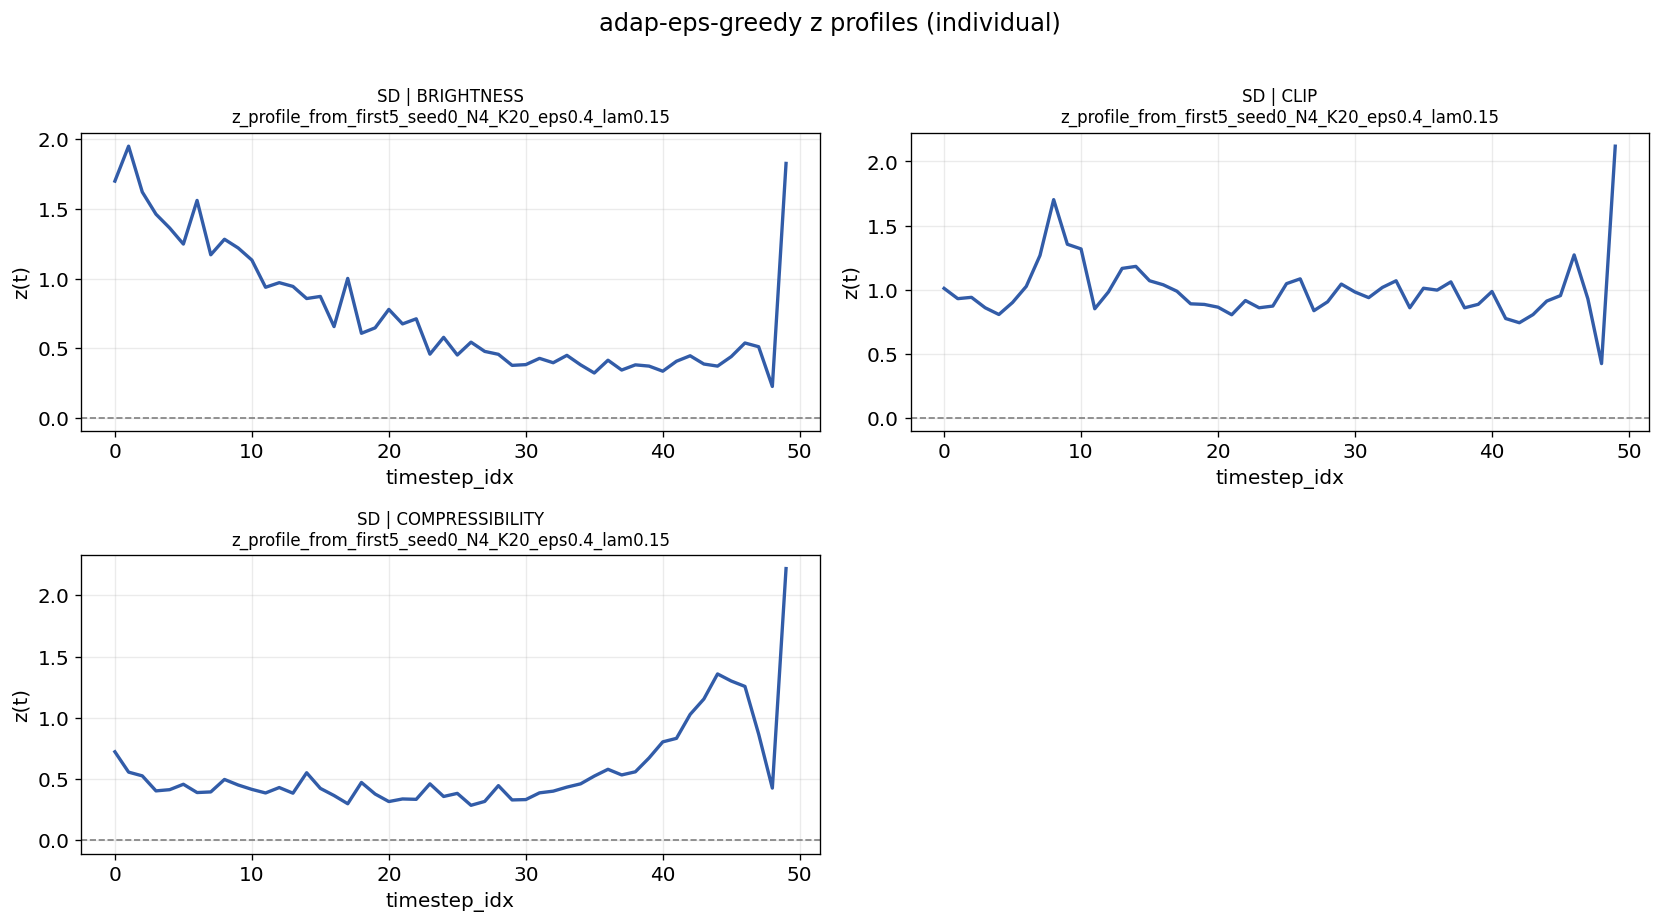

In [3]:
# Individual profile plots
n = len(profiles_df)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 3.8 * nrows), squeeze=False)

for i, (_, row) in enumerate(profiles_df.iterrows()):
    r = i // ncols
    c = i % ncols
    ax = axes[r][c]

    z = row['z_values']
    x = np.arange(len(z))

    ax.plot(x, z, linewidth=2.0, color='#325CA8')
    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0)
    ax.set_title(f"{row['model']} | {row['reward']}\n{row['profile_id']}", fontsize=10)
    ax.set_xlabel('timestep_idx')
    ax.set_ylabel('z(t)')

for j in range(n, nrows * ncols):
    r = j // ncols
    c = j % ncols
    axes[r][c].axis('off')

fig.suptitle('adap-eps-greedy z profiles (individual)', y=1.01)
plt.tight_layout()
plt.show()

In [4]:
# Build grouped mean and SE by (model, reward, n_steps)
group_rows = []
for (model, reward, n_steps), sub in profiles_df.groupby(['model', 'reward', 'n_steps'], sort=True):
    mats = np.vstack(sub['z_values'].to_list())
    n_profiles = int(mats.shape[0])

    mean = mats.mean(axis=0)
    if n_profiles > 1:
        se = mats.std(axis=0, ddof=1) / np.sqrt(n_profiles)
    else:
        se = np.full(n_steps, np.nan)

    group_rows.append({
        'model': model,
        'reward': reward,
        'n_steps': int(n_steps),
        'n_profiles': n_profiles,
        'z_mean_curve': mean,
        'z_se_curve': se,
    })

group_df = pd.DataFrame(group_rows).sort_values(['model', 'reward', 'n_steps']).reset_index(drop=True)
group_df[['model', 'reward', 'n_steps', 'n_profiles']]

,model,reward,n_steps,n_profiles
0,SD,BRIGHTNESS,50,1
1,SD,CLIP,50,1
2,SD,COMPRESSIBILITY,50,1


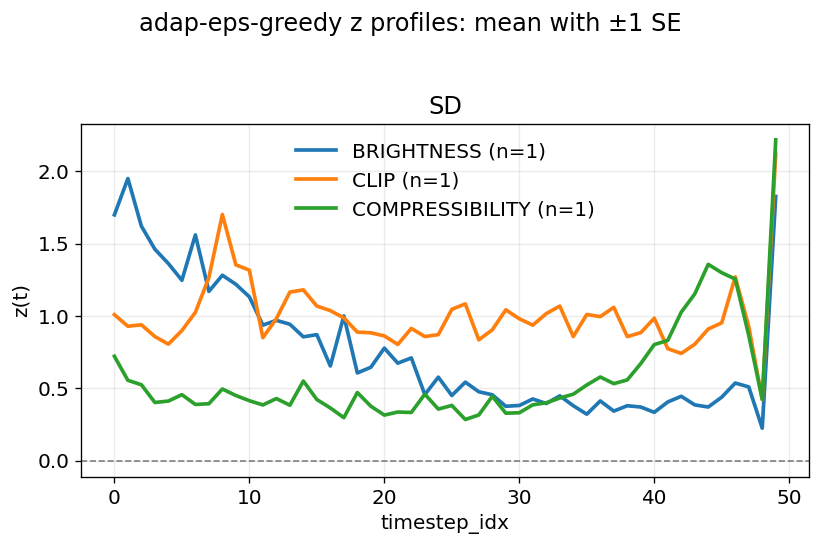

In [5]:
# Overlay by model with mean curves and ±1 SE shading
models = sorted(group_df['model'].unique())
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 4.4), squeeze=False)

for i, model in enumerate(models):
    ax = axes[0][i]
    sub = group_df[group_df['model'] == model].sort_values('reward')

    for _, row in sub.iterrows():
        x = np.arange(int(row['n_steps']))
        m = row['z_mean_curve']
        se = row['z_se_curve']
        n_profiles = int(row['n_profiles'])

        line = ax.plot(x, m, linewidth=2.2, label=f"{row['reward']} (n={n_profiles})")[0]

        if n_profiles > 1 and np.isfinite(se).any():
            ax.fill_between(x, m - se, m + se, alpha=0.22, color=line.get_color())

    ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0)
    ax.set_title(model)
    ax.set_xlabel('timestep_idx')
    if i == 0:
        ax.set_ylabel('z(t)')
    ax.legend(frameon=False)

fig.suptitle('adap-eps-greedy z profiles: mean with ±1 SE', y=1.03)
plt.tight_layout()
plt.show()

In [6]:
r_z = []
for i, (_, row) in enumerate(profiles_df.iterrows()):
    r_z.append((row['reward'], row['z_values']))

In [34]:
np.mean(r_z[2][1] >=0.5587)

np.float64(0.24)